# ANN example PyTorch

A faster and GPU compatible deep learning library is ```PyTorch```. However, the syntax is different from that of ```Keras``` and we therefore repeat the same example, but this time building an ANN using ```PyTorch```. 

## 1) Preparation

As usual, we first call the standard libraries for visualization and numerical operations as well as some helper functions for plotting:

In [1]:
import sys  
sys.path.insert(1, '../15 Codes')
from Auxiliary import *

In [ ]:
#just checking
#import Auxiliary 
#print(dir(Auxiliary))

Next, we call the libraries necessary for model evaluation:

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

And finally we call the ```PyTorch``` libraries

In [3]:
import torch
import torch.nn as nn # for building the ANN
import torch.optim as optim # optimizer
import torch.nn.functional as nnf # we need later for calculating probabilities from logits

<br>

## 2) The Data Set

Standard classification algorithms (SVM, GMMs etc) struggle with oddly shaped cluster. For the purpose of this demonstration, we want to challange the model and therefore work with a dataset that has spiral like cluster.  

In [4]:
def generate_spiral(n_samples_per_class: int = 500, n_classes: int = 5, noise: float = 0.2):
    
    X = np.zeros((n_samples_per_class * n_classes, 2))
    Y = np.zeros((n_samples_per_class * n_classes,), dtype = int)

    for j in range(n_classes):
        
        ix = range(j * n_samples_per_class, (j + 1) * n_samples_per_class)
        r  = np.linspace(0.0, 1, n_samples_per_class)
        t  = np.linspace(j * 4, (j + 1) * 4, n_samples_per_class) + np.random.randn(n_samples_per_class) * noise
        
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        Y[ix] = j

    return X, Y

In [5]:
NClasses = 5 #we generate five classes, defined by their x1 and x2 coordinates
X, Y     = generate_spiral(n_classes = NClasses)

Plotting the spiral data set:

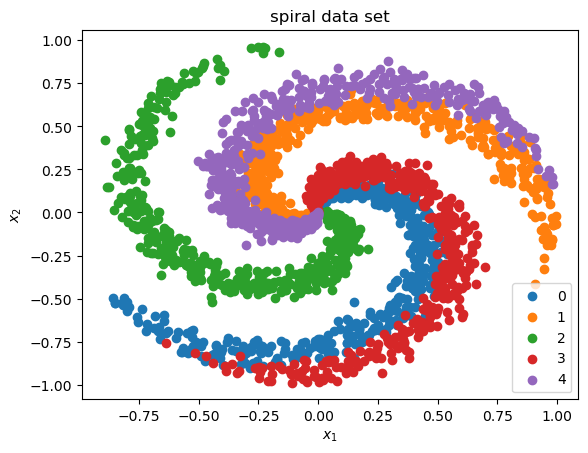

In [6]:
PlotClasses(X, Y)

In the next steps, we split the dataset and scale it as we did in the other modules.

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [8]:
scaler   = StandardScaler()
X_trainS = scaler.fit_transform(X_train)
X_testS  = scaler.transform(X_test)

<br>

# 3) The Model

**3.1) Building the Model**

We are now creating the ANN using ```PyTorch```. In the simplest version, we need an<br> 
<br>
- input layer ingesting the data,<br>
- add an activation function and<br>
- an output layer.<br>

Here, since we are working on a classification problem, the output layer needs to have a ```softmax``` activation function at the end (see lecture). Using the ```softmax``` activation function, we **turn the output of the output layer into probabilities** for the class assignments for each data point. Therefore, the output layer needs ```NClasses``` output neurons: each neuron will be voting for each of the five classes.<br>
For that purpose we added a softmax layer in ```Keras```. ```PyTorch``` does that automatically if we define cross entropy as loss function later.

3.1.1) Preparing Data for ```PyTorch```<br>
<br>

```PyTorch``` is usually 2-5 times faster than ```Keras```. In order to speed-up the code even further, it is possible to run the model on your **GPU using Cuda** (see Chem 277B). That can result in a total gain of two orders of magintude in speed! In order to be agnostic about the device (default CPU or GPU), we add one line of code checking for the devices: 

In [9]:
def test_cuda():
    print("PyTorch version: ", torch.__version__)
    print("CUDA version: ", torch.version.cuda)
    print("CUDA Available: ", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("Number of GPUs: ", torch.cuda.device_count())
        print("GPU Name: ", torch.cuda.get_device_name(0))

if __name__ == "__main__":
    test_cuda()

PyTorch version:  2.10.0+cpu
CUDA version:  None
CUDA Available:  False


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device) # should be CPU unless you run Cuda (see Chem 277B)

cpu


Another key difference is that ```PyTorch``` works with ```torch.tensor```, not with ```np.array```. The advantage is that we can set the training and test dataset to the desired device, once we have converted it to a ```torch.tensor```. 

In [11]:
X_train_t = torch.tensor(X_trainS, dtype=torch.float32).to(device) # tensors are float 32, not float 64
Y_train_t = torch.tensor(Y_train, dtype=torch.long).to(device)
X_test_t  = torch.tensor(X_testS, dtype=torch.float32).to(device)

<br>

3.1.2) Preparing the actual Model<br>
<br>

Now we are ready for building the actual model. Since we want to be able to run the model on any device, we need to set any instance of the model ```.to(device)``` as well.

In [12]:
Nneuron  = 64 # we provide a number of neurons for the input layer --> you can try to explore model performance for Nneuron = 2, 5, 10, etc

Buliding the actual model (minimal setup):

In [13]:
class My_Torch_Model(nn.Module):
    def __init__(self, NClasses, Nfeatures, Nneuron: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Nfeatures, Nneuron), # input layer
            nn.ReLU(),
            nn.Linear(Nneuron, NClasses)  # output layer
            # note: in Keras, you would add a softmax layer here for classification. 
            # PyTorch does that automatically if we define cross entropy as loss later
        )
    # in contrast to Keras, we need to add the forward method explicitly
    def forward(self, x):
        return self.net(x)

Next, we assign the model to the device, add an optimizer (```Adam```) and cross entropy as loss function.

In [14]:
model        = My_Torch_Model(NClasses, X.shape[1], Nneuron).to(device)
leaning_rate = 0.01
optimizer    = optim.Adam(model.parameters(), lr = leaning_rate)
criterion    = nn.CrossEntropyLoss()

<br>

**3.2) Training and Evaluating the Model**

As with the ```Keras``` example, are going the visualize the learning process of the model. Note, that ```PyTorch``` does not have a ```history``` function like ```Keras```. We nevertheless return the current loss via ```print``` and save it in an ```np.array``` in order to keep track of it. Also running a validation set during training has to set up manually in ```PyTorch```.<br>
Thus, ```PyTorch``` is very minimalistic, but as you will see, much faster than ```Keras```.<br>

3.3.1) Visualization of the learning process

Setting epoch marks for snapshots:

In [15]:
epoch_marks = [1, 5, 10, 20, 50, 100, 200, 500]
snapshots   = [None]*len(epoch_marks)

Running training and save snapshots:

In [16]:
Emax = epoch_marks[-1]
Loss = np.zeros((Emax,))

The training loop:

In [17]:
ecurrent = 0
for e in range(Emax):

    model.train()
    
    optimizer.zero_grad() # resetting the gradient
    
    out  = model(X_train_t)
    loss = criterion(out, Y_train_t)
    loss.backward() #feeding loss into backward method
    
    optimizer.step()

    Loss[e] = loss

    print(f"current epoch: {e+1}\ncurrent loss: {loss: .2f}")

    # not needed for actual training, but for snapshots
    if e+1 == epoch_marks[ecurrent]: 
        xx, yy, Z           = Compute_Boundary(X_trainS, model, torch_model=True)
        snapshots[ecurrent] = (e+1, xx, yy, Z)
        ecurrent += 1

C:\Users\MMH_user\AppData\Local\Temp\ipykernel_16540\2788917543.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  Loss[e] = loss


current epoch: 1
current loss:  1.65
current epoch: 2
current loss:  1.55
current epoch: 3
current loss:  1.47
current epoch: 4
current loss:  1.40
current epoch: 5
current loss:  1.35
current epoch: 6
current loss:  1.32
current epoch: 7
current loss:  1.29
current epoch: 8
current loss:  1.27
current epoch: 9
current loss:  1.25
current epoch: 10
current loss:  1.24
current epoch: 11
current loss:  1.23
current epoch: 12
current loss:  1.22
current epoch: 13
current loss:  1.21
current epoch: 14
current loss:  1.20
current epoch: 15
current loss:  1.19
current epoch: 16
current loss:  1.18
current epoch: 17
current loss:  1.17
current epoch: 18
current loss:  1.16
current epoch: 19
current loss:  1.15
current epoch: 20
current loss:  1.14
current epoch: 21
current loss:  1.12
current epoch: 22
current loss:  1.11
current epoch: 23
current loss:  1.10
current epoch: 24
current loss:  1.09
current epoch: 25
current loss:  1.08
current epoch: 26
current loss:  1.07
current epoch: 27
cur

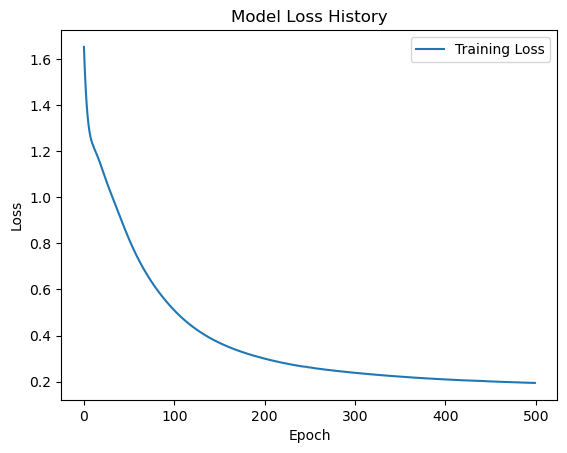

In [18]:
#plotting loss over epochs
plt.plot(Loss, label = 'Training Loss')
plt.title('Model Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plotting decission boundaries as a function of epochs:

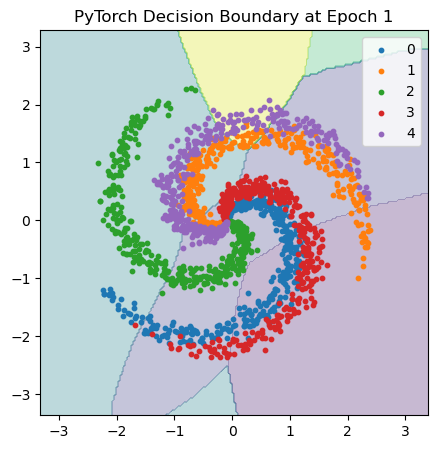

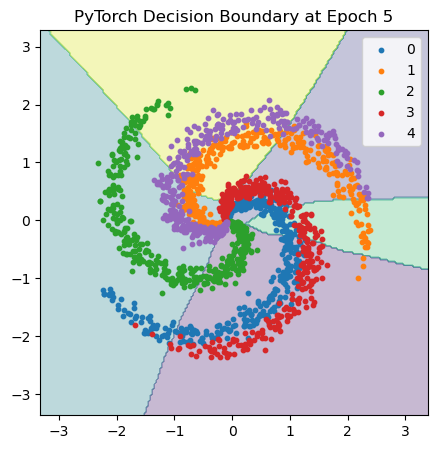

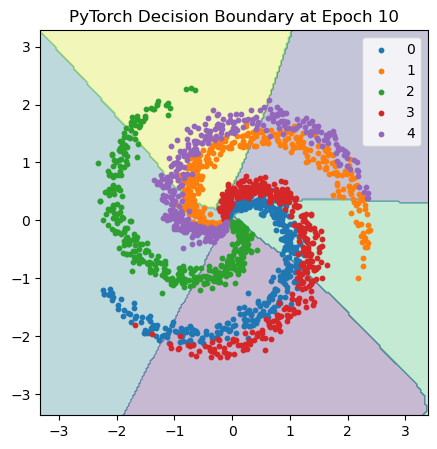

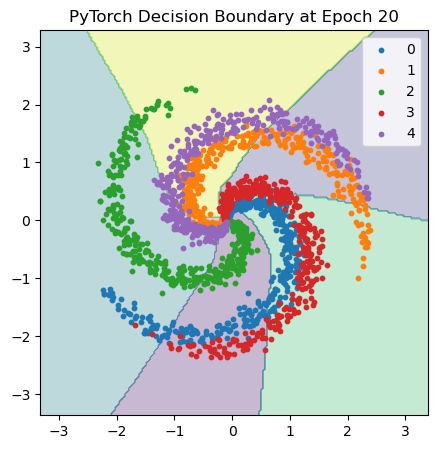

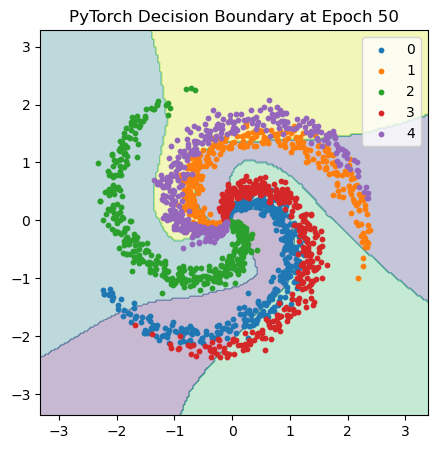

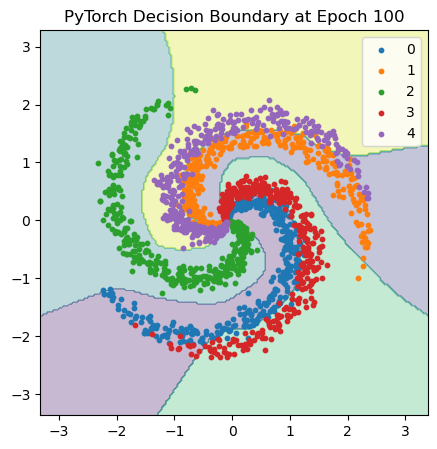

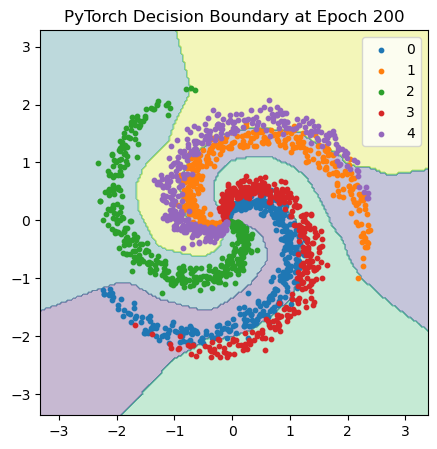

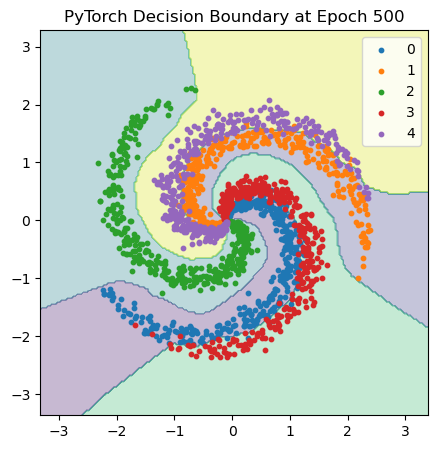

In [19]:
# Plot snapshots
for epoch, xx, yy, Z in snapshots:
    Plot_Boundary_Snapshot(X_trainS, Y_train, xx, yy, Z, f"PyTorch Decision Boundary at Epoch {epoch}")

<br>
3.3.2) Evaluation

Next, we take the test data set in order to predict the labels and compare the predictions to the true labels as we did with in the case of the other methods by generating a histogram of the probabilities and a confusion chart.

In [20]:
logits = model(X_test_t) # the probabilities are returned as log
PredY  = torch.argmax(logits, dim = 1).numpy()
P      = nnf.softmax(logits, dim=1).detach().numpy() 

In [21]:
Labels    = ["Class " + str(c) for c in range(NClasses)] # labels for plotting
LablesNum = list(np.arange(NClasses))

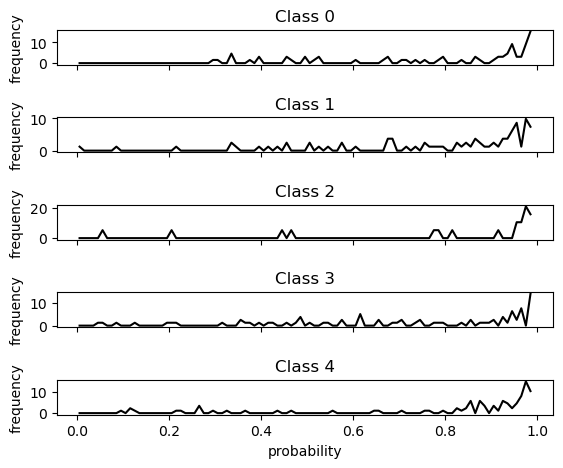

In [22]:
plot_entropy(P, Y_test, Labels, LablesNum)

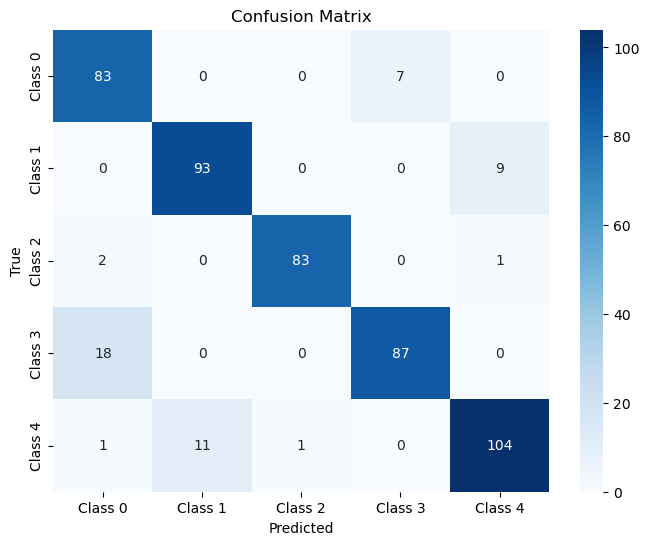

In [23]:
plot_confusion(PredY, Y_test, Labels)